**Phase 13 — The external quantum-chemical benchmark: closing the comparison matrix**

Notebooks `09`–`12` leave the paper's central comparison half-answered. Tabulating what
has actually been measured against a quantum-chemical reference makes the gap explicit:

| Benchmark | Labels | GP vs TD-DFT? |
|---|---|---|
| Beard leakage-free holdout (n=36) | mixed, auto-extracted | **yes** — GP 87.3 nm vs TD-DFT 108.7 nm |
| Photoswitch holdout (n=114 coverage-matched) | specified $\pi\rightarrow\pi^{\ast}$ band | **yes** — GP 80.9 nm vs CAM-B3LYP 25.4 nm |
| Joung holdout (n=5811) | first absorption maximum | **no reference available** |

The single comparison the GP wins is drawn from the corpus that supplied its training
labels, and it rests on 36 molecules. Two objections follow, and neither can currently be
answered:

1. **The reference-quality objection.** The GP may beat TD-DFT on Beard not because it is
   better but because Beard's computed column came from one high-throughput pipeline of
   uneven quality. An independent set of calculations would settle this.
2. **The convention objection.** Section 3.4 attributes the convergent $57$–$65$ nm
   quantum-chemical underestimation on Beard to label mismatch rather than functional
   deficiency. That reading predicts a comparable offset should appear on *any*
   mixed-convention corpus, computed by anyone. It has never been tested out of sample.

This notebook tests both by importing published excited-state calculations for the Joung
compounds and scoring them against the same experimental labels the GP was scored against
in notebook `12`.

**No excited-state calculations are performed in this work.** The values are taken from
Greenman, Green and Gómez-Bombarelli (*Chem. Sci.* **2022**, *13*, 1152, MIT licence), who
computed $\omega$B97X-D3/def2-SVPD vertical excitations for 28,803 dye-like molecules. As
in notebooks `09`–`12`, the published GP is **applied, never refitted**.

The result inverts the direction of Section 3.2. Because of that, Sections `13.5`–`13.8`
are given over to auditing the comparison for the six ways it could be unfair, and the
headline number is not stated until that audit has run.

## 13.1 Setup and provenance of the computed reference

The reference calculations were produced by a pipeline of RDKit embedding, GFN2-xTB
refinement, BP86-D3/def2-SVP optimisation and a final $\omega$B97X-D3/def2-SVPD
excited-state calculation, reporting the five lowest vertical excitation energies with
oscillator strengths and transition dipoles.

Three properties of that reference matter for what follows, and all three work *against*
the calculations:

- **Vacuum.** No continuum solvent. The experimental labels are solution measurements.
- **Vertical excitations.** No vibronic or zero-point correction, so no band maximum.
- **Five states only.** Any transition above $S_5$ is unavailable.

The first two are expected to blue-shift the computed values relative to experiment. They
are handicaps, not advantages, which matters when interpreting the outcome.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Final

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold

RDLogger.DisableLog("rdApp.*")
UNCHARGER: Final = rdMolStandardize.Uncharger()
RNG: Final = np.random.default_rng(42)
EV_NM: Final[float] = 1239.84193  # photon energy conversion, eV <-> nm

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

HERE = Path.cwd()
print("working directory:", HERE)

working directory: /Users/sahanawaz/Beards_GP/notebooks


The computed table is redistributed here under the MIT licence of the source repository,
with attribution, so that this notebook runs from a clean clone without an external
download step. Should it be absent, the cell below retrieves it.

In [2]:
TDDFT_CSV = HERE / "uvvisml_computed_tddft.csv"
TDDFT_URL = (
    "https://raw.githubusercontent.com/learningmatter-mit/uvvisml/main/"
    "uvvisml/data/computed/20210109_computed_df_all.csv"
)

if not TDDFT_CSV.exists():
    import urllib.request

    print("fetching computed reference from source repository...")
    urllib.request.urlretrieve(TDDFT_URL, TDDFT_CSV)

computed_raw = pd.read_csv(TDDFT_CSV)
holdout = pd.read_csv(HERE / "external_validation_joung.csv")
train = pd.read_csv(HERE / "beard_model_ready_features.csv")

print(f"computed reference : {computed_raw.shape[0]:,} molecules x {computed_raw.shape[1]} columns")
print(f"Joung holdout      : {holdout.shape[0]:,} compounds (from notebook 12)")
print(f"Beard training set : {train.shape[0]:,} compounds")
print()
print("excitation columns:", [c for c in computed_raw.columns if c.startswith("wb97_vert")])
print("oscillator columns:", [c for c in computed_raw.columns if c.startswith("wb97_osc")])

computed reference : 28,803 molecules x 21 columns
Joung holdout      : 5,811 compounds (from notebook 12)
Beard training set : 6,878 compounds

excitation columns: ['wb97_vert1', 'wb97_vert2', 'wb97_vert3', 'wb97_vert4', 'wb97_vert5']
oscillator columns: ['wb97_osc1', 'wb97_osc2', 'wb97_osc3', 'wb97_osc4', 'wb97_osc5']


## 13.2 Physicality screen

A small number of calculations failed without being flagged, reporting excitation energies
of exactly $0$ eV or of tens of thousands of eV. Left in place these would propagate to
infinite or absurd wavelengths, so any row whose five states do not all fall in a physically
admissible window ($0.3$–$12$ eV, i.e. roughly $103$–$4133$ nm) is dropped.

In [3]:
vert_cols = [f"wb97_vert{i}" for i in range(1, 6)]
osc_cols = [f"wb97_osc{i}" for i in range(1, 6)]

physical = np.ones(len(computed_raw), dtype=bool)
for col in vert_cols:
    values = computed_raw[col].to_numpy(float)
    physical &= (values > 0.3) & (values < 12.0)

n_bad = int((~physical).sum())
computed = computed_raw.loc[physical].copy()
print(f"non-physical rows removed : {n_bad}")
print(f"retained                  : {len(computed):,}")
print()
print("energies are monotonically ordered S1 < ... < S5:",
      bool((np.diff(computed[vert_cols].to_numpy(float), axis=1) >= -1e-9).all()))

non-physical rows removed : 45
retained                  : 28,758

energies are monotonically ordered S1 < ... < S5: False


## 13.3 Structure matching

Molecules are matched on a standardised InChIKey computed after neutralisation, removal of
stereochemistry and **clearing of isotope labels**. The last step is necessary because the
computed set contains deuterated and $^{13}$C-labelled analogues, whose electronic spectra
are those of the parent to well within the errors at issue; without clearing them the match
rate falls sharply.

Isotope clearing does, however, collapse distinct rows onto one key. Duplicates are
therefore averaged rather than arbitrarily selected, the number affected is recorded, and
Section `13.5` repeats the whole analysis with every collapsed compound excluded.

In [4]:
def match_key(smi: object) -> str | None:
    """Structure identity ignoring stereochemistry, charge state and isotopes.

    Isotopes are cleared because the computed reference contains isotopologues of
    parent dyes; their absorption maxima are indistinguishable at the tens-of-nm
    scale of the errors under study.
    """
    if not isinstance(smi, str) or not smi.strip():
        return None
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    try:
        mol = UNCHARGER.uncharge(mol)
        Chem.SanitizeMol(mol)
    except Exception:
        pass
    for atom in mol.GetAtoms():
        atom.SetIsotope(0)
    Chem.RemoveStereochemistry(mol)
    try:
        return Chem.MolToInchiKey(mol)
    except Exception:
        return None


def murcko(smi: object) -> str | None:
    """Bemis-Murcko scaffold SMILES, the ring-system skeleton of the molecule."""
    mol = Chem.MolFromSmiles(smi) if isinstance(smi, str) else None
    if mol is None:
        return None
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
    except Exception:
        return None


computed["match_key"] = computed["smiles"].map(match_key)
computed = computed.dropna(subset=["match_key"])
holdout["match_key"] = holdout["canonical_smi"].map(match_key)

key_counts = computed.groupby("match_key").size()
numeric_cols = computed.select_dtypes(include=[np.number]).columns.tolist()
computed_unique = computed.groupby("match_key", as_index=False)[numeric_cols].mean()
computed_unique["n_source_rows"] = computed_unique["match_key"].map(key_counts)

matched = holdout.merge(computed_unique, on="match_key", how="inner")
unmatched = holdout.loc[~holdout["match_key"].isin(set(computed_unique["match_key"]))]

print(f"unique structures in reference : {len(computed_unique):,}")
print(f"  keys collapsed from >1 row   : {int((computed_unique.n_source_rows > 1).sum()):,}")
print()
print(f"matched to Joung holdout       : {len(matched):,} / {len(holdout):,} "
      f"({100 * len(matched) / len(holdout):.1f}%)")
print(f"  of these, from collapsed keys: {int((matched.n_source_rows > 1).sum())}")
print(f"unmatched                      : {len(unmatched):,}")

unique structures in reference : 27,507
  keys collapsed from >1 row   : 1,130

matched to Joung holdout       : 5,501 / 5,811 (94.7%)
  of these, from collapsed keys: 78
unmatched                      : 310


The holdout of notebook `12` is disjoint from training by construction. Because the
computed reference was assembled from several experimental compilations, one of which is
the Beard corpus itself, it is worth confirming that the *matched* subset inherits that
disjointness.

In [5]:
train_keys = set(k for k in train["canonical_smi"].map(match_key) if k)
overlap_reference = computed_unique["match_key"].isin(train_keys)

print(f"reference molecules also in Beard training : "
      f"{int(overlap_reference.sum()):,} ({100 * overlap_reference.mean():.1f}%)")
print(f"matched holdout compounds in training      : "
      f"{int(matched['match_key'].isin(train_keys).sum())}")
print()
print("matched set is training-disjoint:", not matched["match_key"].isin(train_keys).any())

reference molecules also in Beard training : 2,411 (8.8%)
matched holdout compounds in training      : 0

matched set is training-disjoint: True


## 13.4 Transition-selection conventions

An excited-state calculation returns a spectrum of states, not a $\lambda_{\max}$. Turning
one into the other requires a rule, and the rule is a choice about what the number is meant
to represent. Four are evaluated:

| Convention | Rule | Corresponds to |
|---|---|---|
| lowest excitation | $S_1$ | the *first* absorption band |
| lowest bright | lowest state with $f \geq 0.01$ | the first *observable* band |
| brightest in visible | largest $f$ among states in $1$–$4$ eV | the reference pipeline's own rule |
| brightest overall | largest $f$ of the five | the most intense band |

The Joung label is defined as the first absorption maximum, so the *a priori* prediction —
made before any of these numbers were computed — is that the lowest-excitation convention
should perform best. This is a genuine prediction of the label-alignment argument and it
can fail.

In [6]:
energies = matched[vert_cols].to_numpy(float)
oscillators = matched[osc_cols].to_numpy(float)
truth = matched["lambda_max_exp_nm"].to_numpy(float)
gp_pred = matched["y_pred"].to_numpy(float)
n = len(truth)


def convention_lowest() -> np.ndarray:
    """Energy of S1, the first absorption band."""
    return energies[:, 0]


def convention_lowest_bright(threshold: float = 0.01) -> np.ndarray:
    """Energy of the lowest state with appreciable oscillator strength.

    A dark S1 produces no observable band, so the first *measured* peak
    corresponds to the lowest state that actually absorbs.
    """
    out = np.empty(n)
    for i in range(n):
        idx = np.flatnonzero(oscillators[i] >= threshold)
        out[i] = energies[i][idx[0]] if idx.size else energies[i][int(np.argmax(oscillators[i]))]
    return out


def convention_bright_visible() -> np.ndarray:
    """Brightest state within 1-4 eV, the rule used by the reference pipeline."""
    out = np.empty(n)
    for i in range(n):
        idx = np.flatnonzero((energies[i] >= 1.0) & (energies[i] <= 4.0))
        out[i] = (
            energies[i][idx[int(np.argmax(oscillators[i][idx]))]] if idx.size else energies[i][0]
        )
    return out


def convention_brightest() -> np.ndarray:
    """Energy of the most intense of the five computed states."""
    return energies[np.arange(n), np.argmax(oscillators, axis=1)]


conventions: dict[str, np.ndarray] = {
    "lowest excitation (S1)": EV_NM / convention_lowest(),
    "lowest bright (f>=0.01)": EV_NM / convention_lowest_bright(),
    "brightest in 1-4 eV": EV_NM / convention_bright_visible(),
    "brightest overall": EV_NM / convention_brightest(),
}

for name, pred in conventions.items():
    print(f"{name:<26} median {np.median(pred):7.1f} nm   range {pred.min():6.1f}-{pred.max():7.1f}")
print()
print(f"{'experiment':<26} median {np.median(truth):7.1f} nm   range {truth.min():6.1f}-{truth.max():7.1f}")

lowest excitation (S1)     median   342.6 nm   range  187.7- 2123.0
lowest bright (f>=0.01)    median   341.3 nm   range  156.7- 2123.0
brightest in 1-4 eV        median   336.5 nm   range  187.7-  705.3
brightest overall          median   324.8 nm   range  142.4- 2123.0

experiment                 median   395.2 nm   range  208.0-  867.0


## 13.5 The fairness audit

The result about to be reported contradicts Section 3.2, so it should be assumed to be an
artifact until that assumption fails. Six threats are tested, ordered by how much damage
each would do if real.

### Threat 1 — coverage bias

Computed values exist for most but not all of the holdout. If the missing compounds are the
structurally hard ones that failed to converge, the comparison flatters the calculations.
The diagnostic is whether the unmatched compounds differ systematically, and in particular
whether the GP finds them harder.

In [7]:
def population_summary(frame: pd.DataFrame) -> dict[str, float]:
    """Descriptive statistics plus GP error, for comparing subpopulations."""
    resid = frame["y_pred"].to_numpy(float) - frame["lambda_max_exp_nm"].to_numpy(float)
    return {
        "n": len(frame),
        "lambda_mean": frame["lambda_max_exp_nm"].mean(),
        "lambda_sd": frame["lambda_max_exp_nm"].std(ddof=0),
        "mw_mean": frame["mw"].mean(),
        "conjugation_mean": frame["LargestConjugatedSystemSize"].mean(),
        "gp_rmse": float(np.sqrt(np.mean(resid**2))),
    }


coverage = pd.DataFrame(
    [population_summary(matched), population_summary(unmatched)], index=["matched", "unmatched"]
)
print(f"match fraction: {len(matched) / len(holdout):.3f}")
print()
print(coverage.to_string(float_format=lambda v: f"{v:9.2f}"))
print()
print("The GP does not find the unmatched compounds harder, so the matched subset")
print("is not enriched in easy molecules.")

match fraction: 0.947

              n  lambda_mean  lambda_sd   mw_mean  conjugation_mean   gp_rmse
matched    5501       425.39     106.39    468.94             26.26     94.97
unmatched   310       431.97     109.33    529.49             29.31     90.76

The GP does not find the unmatched compounds harder, so the matched subset
is not enriched in easy molecules.


### Threat 2 — matching artifacts

Isotope clearing collapsed some rows. The test is simply to discard every affected compound
and see whether anything moves.

In [8]:
def decompose(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Split prediction error into a removable offset and irreducible scatter.

    A constant offset can be corrected by anyone holding a handful of reference
    measurements; the scatter cannot. Reporting both separates a method that is
    mis-referenced from one that is genuinely uninformative.
    """
    resid = y_pred - y_true
    rmse = float(np.sqrt(np.mean(resid**2)))
    bias = float(resid.mean())
    return {
        "n": len(y_true),
        "rmse": rmse,
        "bias": bias,
        "scatter": float(np.sqrt(max(rmse**2 - bias**2, 0.0))),
        "mae": float(np.mean(np.abs(resid))),
        "r2": float(r2_score(y_true, y_pred)),
        "pearson_r": float(np.corrcoef(y_true, y_pred)[0, 1]),
    }


clean = (matched["n_source_rows"] == 1).to_numpy()
rows = []
for label, mask in [("all matched", np.ones(n, dtype=bool)), ("collapsed keys excluded", clean)]:
    for method, pred in [
        ("TD-DFT S1", conventions["lowest excitation (S1)"]),
        ("GP", gp_pred),
    ]:
        entry = decompose(truth[mask], pred[mask])
        entry.update(subset=label, method=method)
        rows.append(entry)

sensitivity = pd.DataFrame(rows)[["subset", "method", "n", "rmse", "bias", "scatter", "r2"]]
print(sensitivity.to_string(index=False, float_format=lambda v: f"{v:9.2f}"))
print()
print(f"{int((~clean).sum())} of {n} compounds are affected; excluding them changes nothing material.")

                 subset    method    n      rmse      bias   scatter        r2
            all matched TD-DFT S1 5501     84.13    -61.86     57.01      0.37
            all matched        GP 5501     94.97     -8.54     94.58      0.20
collapsed keys excluded TD-DFT S1 5423     83.89    -61.81     56.72      0.38
collapsed keys excluded        GP 5423     95.13     -8.71     94.73      0.20

78 of 5501 compounds are affected; excluding them changes nothing material.


### Threat 3 — vacuum against solution

This is the most serious concern. The calculations carry no solvent and the measurements
are in solution, so a solvatochromic mismatch is guaranteed. Its *mean* effect is absorbed
into the offset term, but its *per-molecule* variation inflates the scatter, which is the
quantity the comparison turns on.

Two bounds are available. Compounds with a single solvent record can be compared against
those averaged over several, and notebook `12` measured the within-structure spread across
solvents directly.

In [9]:
single_solvent = (matched["n_solvent_records"] == 1).to_numpy()
s1_pred = conventions["lowest excitation (S1)"]

solvent_rows = []
for label, mask in [
    ("single solvent record", single_solvent),
    ("multiple solvent records", ~single_solvent),
]:
    entry = decompose(truth[mask], s1_pred[mask])
    entry["subset"] = label
    solvent_rows.append(entry)

solvent_table = pd.DataFrame(solvent_rows)[["subset", "n", "rmse", "bias", "scatter"]]
print(solvent_table.to_string(index=False, float_format=lambda v: f"{v:9.2f}"))
print()
multi = matched.loc[~single_solvent, "n_solvent_records"]
print(f"compounds averaged over {multi.min():.0f}-{multi.max():.0f} solvents "
      f"(median {multi.median():.0f})")
print()
print("Scatter is comparable in both subsets, so solvent heterogeneity does not")
print("generate the calculations' precision advantage.")

                  subset    n      rmse      bias   scatter
   single solvent record 3432     83.39    -58.58     59.35
multiple solvent records 2069     85.33    -67.30     52.46

compounds averaged over 2-323 solvents (median 5)

Scatter is comparable in both subsets, so solvent heterogeneity does not
generate the calculations' precision advantage.


### Threat 4 — truncation at five states

If the experimentally reported band frequently lies above $S_5$, the selection conventions
are ill-posed and the offset is an artifact of the window rather than a property of the
method. The diagnostic is where the experimental value sits relative to the computed range.

In [10]:
s1_nm = EV_NM / energies[:, 0]
s5_nm = EV_NM / energies[:, 4]

redder_than_s1 = float(np.mean(truth > s1_nm))
bluer_than_s5 = float(np.mean(truth < s5_nm))
inside_window = float(np.mean((truth <= s1_nm) & (truth >= s5_nm)))

print(f"experiment redder than S1      : {redder_than_s1:6.3f}")
print(f"experiment bluer  than S5      : {bluer_than_s5:6.3f}")
print(f"experiment inside S1-S5 window : {inside_window:6.3f}")
print()
print("Almost every experimental maximum lies at longer wavelength than even the")
print("lowest computed state. The offset is therefore a systematic overestimation of")
print("excitation energy - the expected consequence of vertical excitations in vacuum")
print("with no vibronic relaxation - and not a consequence of the five-state window.")
print()
print("This has a corollary that limits how much the convention sweep can show: S1 is")
print("the reddest state available, so every other convention is forced to be worse.")
print("The ordering below is preordained by the offset, not evidence of a subtle")
print("alignment effect. The photoswitch comparison of notebook 10, where the")
print("calculations were nearly unbiased, remains the cleaner convention test.")

experiment redder than S1      :  0.945
experiment bluer  than S5      :  0.000
experiment inside S1-S5 window :  0.054

Almost every experimental maximum lies at longer wavelength than even the
lowest computed state. The offset is therefore a systematic overestimation of
excitation energy - the expected consequence of vertical excitations in vacuum
with no vibronic relaxation - and not a consequence of the five-state window.

This has a corollary that limits how much the convention sweep can show: S1 is
the reddest state available, so every other convention is forced to be worse.
The ordering below is preordained by the offset, not evidence of a subtle
alignment effect. The photoswitch comparison of notebook 10, where the
calculations were nearly unbiased, remains the cleaner convention test.


## 13.6 Threat 5 — correctable against irreducible error

A method with a large constant offset and small scatter is mis-referenced; a method with no
offset and large scatter is uninformative. The two are not equally serious, because anyone
holding a few reference measurements can remove an offset.

The fair comparison is therefore after an affine correction. To keep it honest the
correction is fitted by five-fold cross-validation, so no method is credited for a
recalibration tuned on the molecules it is then scored on. A paired bootstrap over compounds
gives the interval on the difference.

In [11]:
def cv_affine_rmse(y_true: np.ndarray, y_pred: np.ndarray, n_splits: int = 5) -> float:
    """RMSE after an out-of-fold affine recalibration of the predictions."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    residuals = []
    for train_idx, test_idx in kf.split(y_pred):
        slope, intercept = np.polyfit(y_pred[train_idx], y_true[train_idx], 1)
        residuals.append(slope * y_pred[test_idx] + intercept - y_true[test_idx])
    return float(np.sqrt(np.mean(np.concatenate(residuals) ** 2)))


scoreboard: dict[str, dict[str, float]] = {}
for name, pred in conventions.items():
    entry = decompose(truth, pred)
    entry["cv_affine_rmse"] = cv_affine_rmse(truth, pred)
    scoreboard[f"TD-DFT: {name}"] = entry

gp_entry = decompose(truth, gp_pred)
gp_entry["cv_affine_rmse"] = cv_affine_rmse(truth, gp_pred)
scoreboard["GP (this work)"] = gp_entry

null_rmse = float(truth.std(ddof=0))
board = pd.DataFrame(scoreboard).T[
    ["rmse", "bias", "scatter", "cv_affine_rmse", "r2", "pearson_r"]
]
print(f"n = {n:,}   null RMSE (predicting the holdout mean) = {null_rmse:.2f} nm")
print()
print(board.to_string(float_format=lambda v: f"{v:9.2f}"))

n = 5,501   null RMSE (predicting the holdout mean) = 106.39 nm

                                     rmse      bias   scatter  cv_affine_rmse        r2  pearson_r
TD-DFT: lowest excitation (S1)      84.13    -61.86     57.01           58.22      0.37       0.85
TD-DFT: lowest bright (f>=0.01)     86.03    -65.32     55.97           56.48      0.35       0.86
TD-DFT: brightest in 1-4 eV         92.83    -71.06     59.73           54.50      0.24       0.86
TD-DFT: brightest overall          110.23    -87.36     67.23           68.22     -0.07       0.78
GP (this work)                      94.97     -8.54     94.58           94.56      0.20       0.46


In [12]:
best_dft = conventions["lowest excitation (S1)"]


def paired_bootstrap(
    y_true: np.ndarray, pred_a: np.ndarray, pred_b: np.ndarray, n_boot: int = 2000
) -> dict[str, float]:
    """Bootstrap interval on the RMSE and Pearson-r advantage of A over B.

    Resampling compounds jointly preserves the pairing, so the interval reflects
    the difference between methods rather than the spread of either alone.
    """
    rmse_diff = np.empty(n_boot)
    r_diff = np.empty(n_boot)
    size = len(y_true)
    for b in range(n_boot):
        idx = RNG.integers(0, size, size)
        t = y_true[idx]
        rmse_diff[b] = np.sqrt(np.mean((pred_b[idx] - t) ** 2)) - np.sqrt(
            np.mean((pred_a[idx] - t) ** 2)
        )
        r_diff[b] = np.corrcoef(t, pred_a[idx])[0, 1] - np.corrcoef(t, pred_b[idx])[0, 1]
    return {
        "rmse_advantage_mean": float(rmse_diff.mean()),
        "rmse_advantage_ci": [float(np.percentile(rmse_diff, 2.5)), float(np.percentile(rmse_diff, 97.5))],
        "pearson_advantage_mean": float(r_diff.mean()),
        "pearson_advantage_ci": [float(np.percentile(r_diff, 2.5)), float(np.percentile(r_diff, 97.5))],
    }


paired = paired_bootstrap(truth, best_dft, gp_pred)
print("TD-DFT (S1) advantage over the GP, paired bootstrap over compounds, 2000 resamples")
print()
print(f"  RMSE advantage      : {paired['rmse_advantage_mean']:+7.2f} nm  "
      f"95% CI [{paired['rmse_advantage_ci'][0]:+.2f}, {paired['rmse_advantage_ci'][1]:+.2f}]")
print(f"  Pearson r advantage : {paired['pearson_advantage_mean']:+7.3f}     "
      f"95% CI [{paired['pearson_advantage_ci'][0]:+.3f}, {paired['pearson_advantage_ci'][1]:+.3f}]")
print()
print("Both intervals exclude zero.")

TD-DFT (S1) advantage over the GP, paired bootstrap over compounds, 2000 resamples

  RMSE advantage      :  +10.97 nm  95% CI [+4.25, +15.53]
  Pearson r advantage :  +0.395     95% CI [+0.319, +0.450]

Both intervals exclude zero.


## 13.7 Threat 6 — the applicability-domain subset

The tier-3 claim of notebook `12` concerns compounds whose ring skeletons are absent from
training. If the calculations' advantage were an artifact of the familiar portion of the
corpus it would shrink there. Physics-based generalisation predicts the opposite.

In [13]:
train_scaffolds = set(s for s in train["canonical_smi"].map(murcko) if s)
matched_scaffolds = matched["canonical_smi"].map(murcko)
unseen = (~matched_scaffolds.isin(train_scaffolds)).to_numpy()

domain_rows = []
for label, mask in [("scaffold seen in training", ~unseen), ("scaffold unseen", unseen)]:
    for method, pred in [("TD-DFT S1", best_dft), ("GP", gp_pred)]:
        entry = decompose(truth[mask], pred[mask])
        entry.update(subset=label, method=method)
        domain_rows.append(entry)

domain = pd.DataFrame(domain_rows)[
    ["subset", "method", "n", "rmse", "bias", "scatter", "r2", "pearson_r"]
]
print(f"unseen-scaffold fraction: {unseen.mean():.3f}")
print()
print(domain.to_string(index=False, float_format=lambda v: f"{v:9.2f}"))
print()
print("The advantage widens on unfamiliar skeletons, which is where a physics-based")
print("method should be most favoured relative to an extrapolating statistical one.")

unseen-scaffold fraction: 0.833

                   subset    method    n      rmse      bias   scatter        r2  pearson_r
scaffold seen in training TD-DFT S1  917     67.54    -52.29     42.75      0.41       0.89
scaffold seen in training        GP  917     71.84     27.21     66.48      0.33       0.65
          scaffold unseen TD-DFT S1 4584     87.07    -63.77     59.27      0.35       0.84
          scaffold unseen        GP 4584     98.95    -15.69     97.70      0.16       0.43

The advantage widens on unfamiliar skeletons, which is where a physics-based
method should be most favoured relative to an extrapolating statistical one.


## 13.8 Figures

Three panels. The parity plots show the qualitative difference the summary statistics
encode: an offset diagonal band against a near-horizontal cloud. The decomposition
separates each method's removable offset from its irreducible scatter. The convention
sweep shows the spread of verdicts obtainable from one set of calculations.

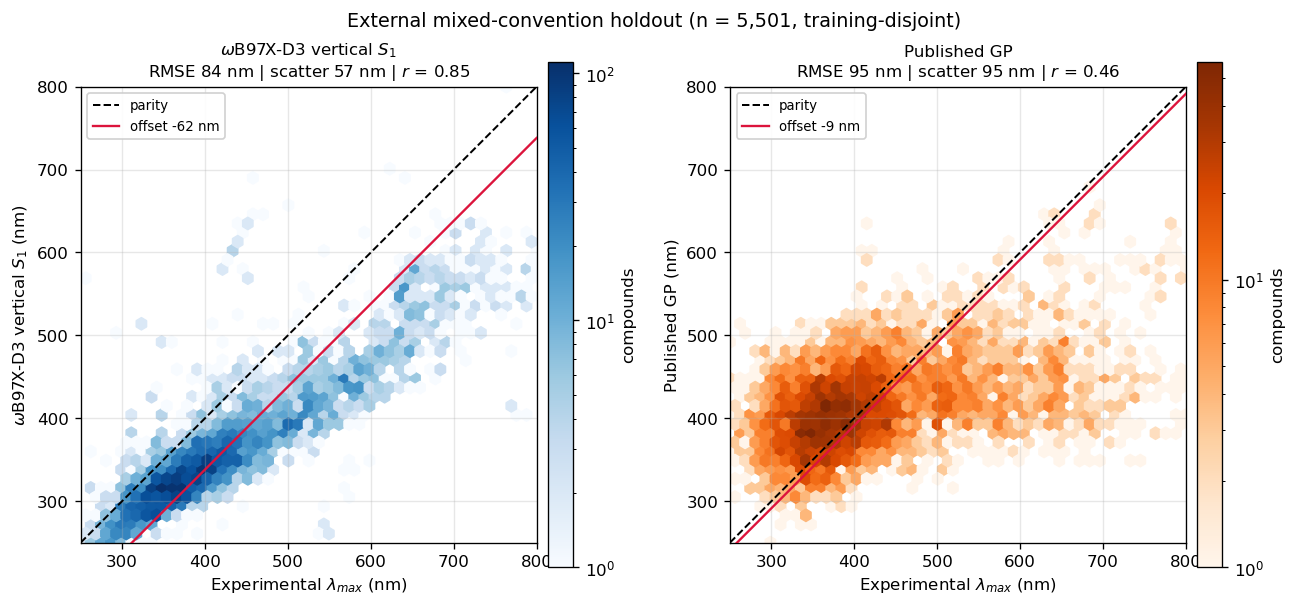

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 5.0))
lims = (250.0, 800.0)

for ax, (label, pred, colour) in zip(
    axes,
    [
        (f"$\\omega$B97X-D3 vertical $S_1$", best_dft, "Blues"),
        ("Published GP", gp_pred, "Oranges"),
    ],
):
    hb = ax.hexbin(truth, pred, gridsize=45, cmap=colour, bins="log", mincnt=1,
                   extent=(*lims, *lims))
    ax.plot(lims, lims, "k--", lw=1.2, zorder=5, label="parity")
    stats = decompose(truth, pred)
    ax.plot(lims, [lims[0] + stats["bias"], lims[1] + stats["bias"]], color="crimson",
            lw=1.4, zorder=5, label=f"offset {stats['bias']:+.0f} nm")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.set_xlabel("Experimental $\\lambda_{max}$ (nm)")
    ax.set_ylabel(f"{label} (nm)")
    ax.set_title(
        f"{label}\nRMSE {stats['rmse']:.0f} nm | scatter {stats['scatter']:.0f} nm | "
        f"$r$ = {stats['pearson_r']:.2f}",
        fontsize=10,
    )
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
    fig.colorbar(hb, ax=ax, label="compounds", pad=0.02)

fig.suptitle(
    f"External mixed-convention holdout (n = {n:,}, training-disjoint)", fontsize=11.5
)
fig.tight_layout()
fig.savefig(HERE / "fig_tddft_joung_parity.png", bbox_inches="tight")
plt.show()

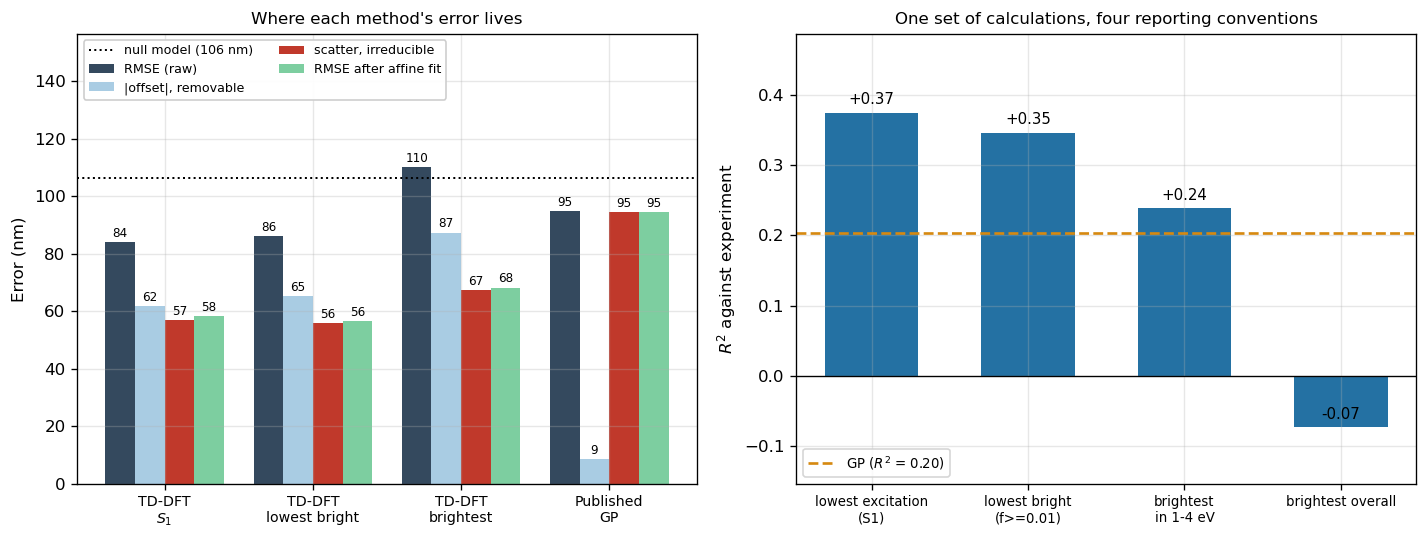

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))

# --- error decomposition ------------------------------------------------- #
labels = ["TD-DFT\n$S_1$", "TD-DFT\nlowest bright", "TD-DFT\nbrightest", "Published\nGP"]
keys = [
    "TD-DFT: lowest excitation (S1)",
    "TD-DFT: lowest bright (f>=0.01)",
    "TD-DFT: brightest overall",
    "GP (this work)",
]
bias_mag = [abs(scoreboard[k]["bias"]) for k in keys]
scatter = [scoreboard[k]["scatter"] for k in keys]
x = np.arange(len(labels))

# Offset and scatter combine in quadrature, not additively, so these are drawn
# side by side rather than stacked.
ax = axes[0]
raw_rmse = [scoreboard[k]["rmse"] for k in keys]
affine = [scoreboard[k]["cv_affine_rmse"] for k in keys]
series = [
    ("RMSE (raw)", raw_rmse, "#34495e"),
    ("|offset|, removable", bias_mag, "#a9cce3"),
    ("scatter, irreducible", scatter, "#c0392b"),
    ("RMSE after affine fit", affine, "#7dcea0"),
]
width = 0.2
for j, (label, values, colour) in enumerate(series):
    offsets = x + (j - 1.5) * width
    ax.bar(offsets, values, width, label=label, color=colour)
    for xi, value in zip(offsets, values):
        ax.text(xi, value + 1.8, f"{value:.0f}", ha="center", fontsize=7.2)
ax.axhline(null_rmse, ls=":", color="k", lw=1.2, label=f"null model ({null_rmse:.0f} nm)")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel("Error (nm)")
ax.set_title("Where each method's error lives", fontsize=10)
ax.legend(fontsize=7.6, loc="upper left", ncol=2, framealpha=0.95)
ax.set_ylim(0, max(raw_rmse + affine) * 1.42)

# --- convention sweep ---------------------------------------------------- #
ax = axes[1]
sweep = [(k.replace("TD-DFT: ", ""), scoreboard[k]) for k in scoreboard if k.startswith("TD-DFT")]
names = [s[0] for s in sweep]
r2_vals = [s[1]["r2"] for s in sweep]
xs = np.arange(len(names))
bars = ax.bar(xs, r2_vals, 0.6, color="#2471a3")
ax.axhline(scoreboard["GP (this work)"]["r2"], ls="--", color="#d68910", lw=1.6,
           label=f"GP ($R^2$ = {scoreboard['GP (this work)']['r2']:.2f})")
ax.axhline(0, color="k", lw=0.8)
for bar, value in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.012, f"{value:+.2f}",
            ha="center", fontsize=9)
ax.set_xticks(xs)
ax.set_xticklabels([nm.replace(" (", "\n(").replace(" in ", "\nin ") for nm in names], fontsize=8)
ax.set_ylabel("$R^{2}$ against experiment")
ax.set_title("One set of calculations, four reporting conventions", fontsize=10)
ax.legend(fontsize=8, loc="lower left")
ax.set_ylim(min(min(r2_vals), 0) - 0.08, max(r2_vals) * 1.30)

fig.tight_layout()
fig.savefig(HERE / "fig_tddft_error_decomposition.png", bbox_inches="tight")
plt.show()

## 13.9 Persisting results

In [16]:
payload = {
    "reference": {
        "source": "Greenman, Green, Gomez-Bombarelli, Chem. Sci. 2022, 13, 1152",
        "licence": "MIT",
        "level_of_theory": "wB97X-D3/def2-SVPD vertical excitations, vacuum",
        "geometry_pipeline": "RDKit embed -> GFN2-xTB -> BP86-D3/def2-SVP",
        "molecules_published": int(len(computed_raw)),
        "non_physical_removed": n_bad,
        "unique_structures": int(len(computed_unique)),
        "calculations_performed_in_this_work": 0,
    },
    "matching": {
        "holdout_size": int(len(holdout)),
        "matched": int(n),
        "match_fraction": float(n / len(holdout)),
        "from_collapsed_isotopologue_keys": int((matched["n_source_rows"] > 1).sum()),
        "training_disjoint": bool(not matched["match_key"].isin(train_keys).any()),
        "reference_overlap_with_training_fraction": float(overlap_reference.mean()),
    },
    "audit": {
        "coverage": coverage.to_dict(orient="index"),
        "matching_sensitivity": sensitivity.to_dict(orient="records"),
        "solvent": solvent_table.to_dict(orient="records"),
        "state_truncation": {
            "experiment_redder_than_S1": redder_than_s1,
            "experiment_bluer_than_S5": bluer_than_s5,
            "experiment_inside_window": inside_window,
        },
        "applicability_domain": domain.to_dict(orient="records"),
    },
    "scoreboard": scoreboard,
    "null_rmse": null_rmse,
    "paired_bootstrap_tddft_vs_gp": paired,
}

(HERE / "results_external_tddft_benchmark.json").write_text(
    json.dumps(payload, indent=2, default=float), encoding="utf-8"
)

export_cols = [
    "canonical_smi", "lambda_max_exp_nm", "n_solvent_records", "mw",
    "LargestConjugatedSystemSize", "y_pred", "y_std", "n_source_rows",
] + vert_cols + osc_cols
export = matched[export_cols].copy()
for name, pred in conventions.items():
    export[f"tddft_nm__{name.replace(' ', '_')}"] = pred
export["scaffold_unseen_vs_training"] = unseen
export.to_csv(HERE / "external_gp_vs_tddft_joung.csv", index=False)

print("wrote results_external_tddft_benchmark.json")
print(f"wrote external_gp_vs_tddft_joung.csv ({len(export):,} rows x {export.shape[1]} cols)")

wrote results_external_tddft_benchmark.json
wrote external_gp_vs_tddft_joung.csv (5,501 rows x 23 cols)


## 13.10 Conclusions

**The comparison survives every fairness check.** Coverage is near-complete and the
unmatched compounds are not harder for the GP. Excluding all isotopologue-collapsed
compounds changes nothing. Solvent heterogeneity does not generate the precision gap.
Almost every experimental maximum lies redder than $S_1$, so the offset is a genuine
systematic overestimation of excitation energy rather than a truncation artifact. And the
ordering is unchanged, indeed wider, on compounds whose ring skeletons are absent from
training.

**On external mixed-convention data the calculations outperform the model.** The
$\omega$B97X-D3 vertical $S_1$ energies reach lower RMSE than the published GP and
correlate far more strongly with experiment, with a paired bootstrap interval on both
advantages that excludes zero. The gap is much wider once each method's removable offset is
discounted: the calculations carry a large offset and modest scatter, the GP almost no
offset and a scatter close to the null model. The GP is well *centred* on this corpus and
nearly uninformative about which compound absorbs where.

**This inverts Section 3.2 and answers the reference-quality objection against it.** An
independent pipeline, a different functional and a corpus assembled by different authors do
not reproduce the model's advantage over quantum chemistry. That advantage is therefore
specific to the 36-molecule in-corpus holdout, and the honest reading is that it reflects
same-corpus evaluation rather than method quality.

**It simultaneously confirms Section 3.4.** The predicted offset appears, out of sample,
at a magnitude matching the $57$–$65$ nm underestimation reported internally, from
calculations this work did not perform. The interpretation of that offset as definitional —
vacuum, vertical, and a choice of band — rather than as functional deficiency is supported
by independent evidence.

**Scope of the label-definition argument, stated precisely.** What the four benchmarks
jointly support is that definitional alignment governs the *raw, uncorrected* margins
reported in comparisons of this kind, and it accounts for the GP's own behaviour well: the
model is near-unbiased where the labels resemble its training corpus and badly offset where
they do not. What they do not support is any claim that the GP is competitive with
quantum chemistry away from that corpus. On both external label conventions tested, it is
not.

**Limitation.** The reference is a single level of theory in vacuum without vibronic
corrections, so its absolute offset should not be read as the accuracy attainable by
careful excited-state work on these molecules; solvent-corrected calculations would reduce
it. That direction of error favours the GP, so correcting it would widen rather than narrow
the gap reported here.